In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder


In [47]:
df = pd.read_csv('Churn.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


Tenure é a única coluna que não possui dados para todos os clientes.

In [49]:
df = df.dropna()


As colunas 'RowNumber', 'CustomerId' e 'Surname' não parecem relevantes para a análise e decedi remové-las

In [1]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

NameError: name 'df' is not defined

In [51]:
df_ohe = pd.get_dummies(df, drop_first=True)
df_ohe.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1.0,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8.0,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1.0,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2.0,125510.82,1,1,1,79084.10,0,False,True,False


In [52]:
target = df_ohe['Exited']
features = df_ohe.drop('Exited', axis=1)


In [53]:
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.25, random_state=12345)

features_train, features_valid, target_train, target_valid = train_test_split(features_train, target_train, test_size=0.25, random_state=12345) 

F1-Score do Teste Árvore de Decisão: 0.5090403337969402
Acurácia: 0.79


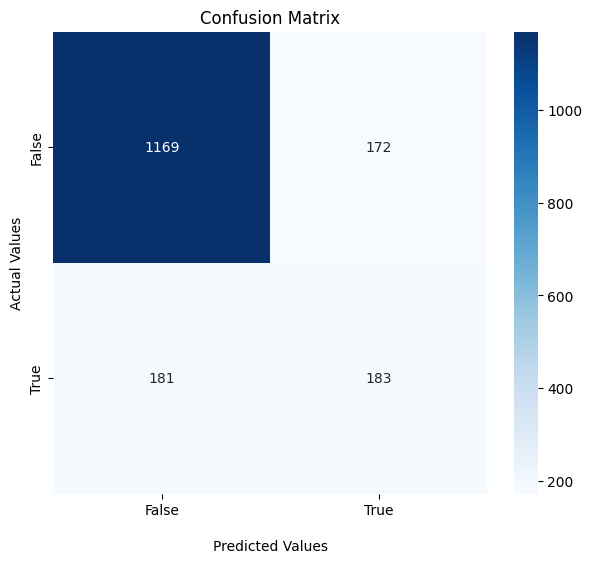

In [54]:
model_dt = DecisionTreeClassifier(random_state=12345)
model_dt.fit(features_train, target_train)
predicted_valid_dt = model_dt.predict(features_valid)
f1_dt=f1_score(target_valid, predicted_valid_dt)
print("F1-Score do Teste Árvore de Decisão:", f1_dt)
accuracy_dt = accuracy_score(target_valid, predicted_valid_dt)
print(f"Acurácia: {accuracy_dt:.2f}")

import matplotlib.pyplot as plt
import seaborn as sns

cm_dt = confusion_matrix(target_valid, predicted_valid_dt)

fig, ax = plt.subplots(figsize=[7,6])

sns.heatmap(cm_dt, annot=True, cmap='Blues', fmt='.0f', ax=ax)

ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values')

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.title('Confusion Matrix')

plt.show()


F1-Score do Teste Regressão Logística: 0.501010101010101
Acurácia: 0.71


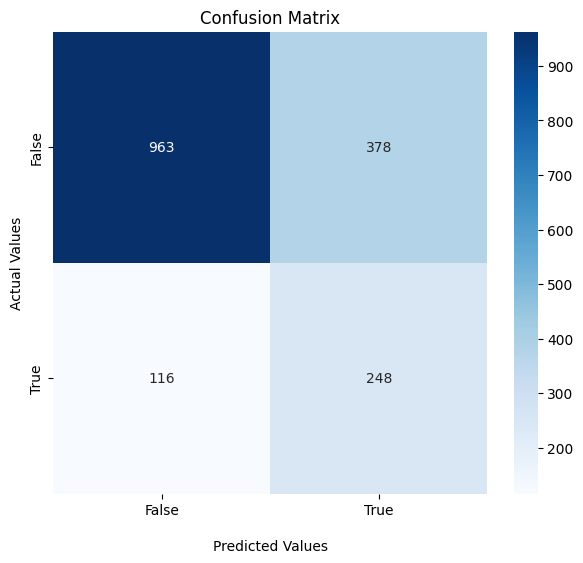

In [55]:
model_lr = LogisticRegression(random_state=12345, solver='liblinear', class_weight = 'balanced')
model_lr.fit(features_train, target_train)
predicted_valid_lr = model_lr.predict(features_valid)
f1_lr = f1_score(target_valid, predicted_valid_lr)
print("F1-Score do Teste Regressão Logística:", f1_lr)
accuracy_lr = accuracy_score(target_valid, predicted_valid_lr)
print(f"Acurácia: {accuracy_lr:.2f}")

cm_lr = confusion_matrix(target_valid, predicted_valid_lr)
fig, ax = plt.subplots(figsize=[7,6])

sns.heatmap(cm_lr, annot=True, cmap='Blues', fmt='.0f', ax=ax)

ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values')

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.title('Confusion Matrix')

plt.show()


F1-Score do Teste Floresta Aleatória: 0.5631768953068592
Acurácia: 0.86


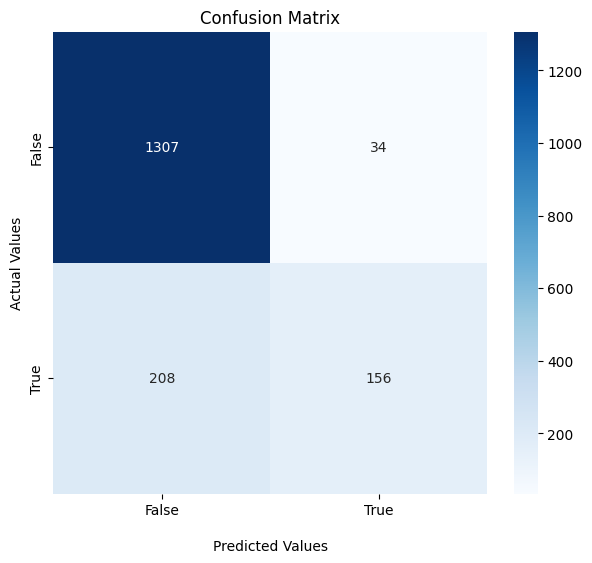

In [56]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=12345)
model_rf.fit(features_train, target_train)
predicted_valid_rf = model_rf.predict(features_valid)
f1_rf = f1_score(target_valid, predicted_valid_rf)
print("F1-Score do Teste Floresta Aleatória:", f1_rf)
accuracy_rf = accuracy_score(target_valid, predicted_valid_rf)
print(f"Acurácia: {accuracy_rf:.2f}")

cm_rf = confusion_matrix(target_valid, predicted_valid_rf)
fig, ax = plt.subplots(figsize=[7,6])

sns.heatmap(cm_rf, annot=True, cmap='Blues', fmt='.0f', ax=ax)

ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values')

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.title('Confusion Matrix')

plt.show()

O modelo que apresentou melhores valores de F1 e acurácia foi a floresta aleatória, desse modo será o modelo utilizado. Contudo, há mais falsos negativos do que positivos, indicando errôneamente que alguns clientes permaneceram no banco, e um valor de F1 abaixo de 0,59, precisando ser ajustado.

In [57]:
%pip install imbalanced-learn


F1-Score do Teste Floresta Aleatória: 0.6283309957924264
Acurácia: 0.84
Precisão: 0.64
Recall: 0.62


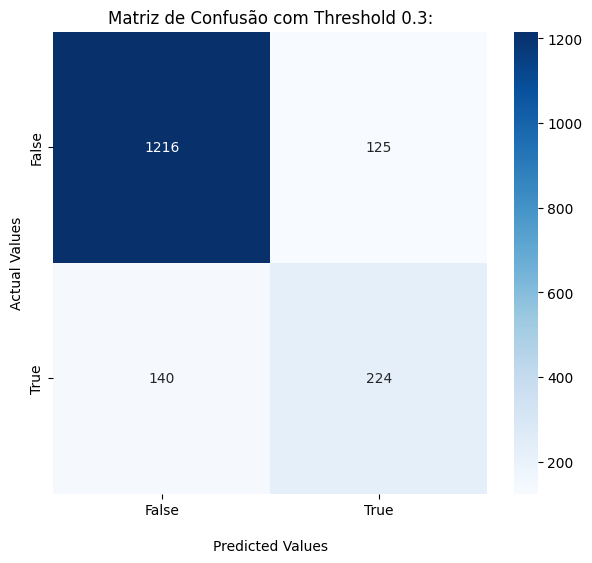

In [58]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, precision_score, classification_report


# Inicializar o modelo Random Forest com class_weight='balanced'
model_rf_balanced = RandomForestClassifier(
    random_state=12345,
    class_weight='balanced',
    n_estimators=100
)

model_rf_balanced.fit(features_train, target_train)
predicted_proba_rf = model_rf_balanced.predict_proba(features_valid)

th = 0.3
predicted_rf_adjusted = (predicted_proba_rf[:,1] > th).astype(int)

#matriz de confusão do modelo ajustado
cm_rf = confusion_matrix(target_valid, predicted_rf_adjusted)
f1_rf = f1_score(target_valid, predicted_rf_adjusted)
print("F1-Score do Teste Floresta Aleatória:", f1_rf)

accuracy_rf = accuracy_score(target_valid, predicted_rf_adjusted)
print(f"Acurácia: {accuracy_rf:.2f}")
precision_rf = precision_score(target_valid, predicted_rf_adjusted)
print(f"Precisão: {precision_rf:.2f}")
recall_rf = recall_score(target_valid, predicted_rf_adjusted)
print(f"Recall: {recall_rf:.2f}")

#gráfico da matrix de confusão
fig, ax = plt.subplots(figsize=[7,6])

sns.heatmap(cm_rf, annot=True, cmap='Blues', fmt='.0f', ax=ax)

ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values')

ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

plt.title('Matriz de Confusão com Threshold 0.3:')

plt.show()


Nessa matrix de confusão ajustada o número de falsos positivos diminuiu e o de verdadeiros negativos e positivos aumentaram. 

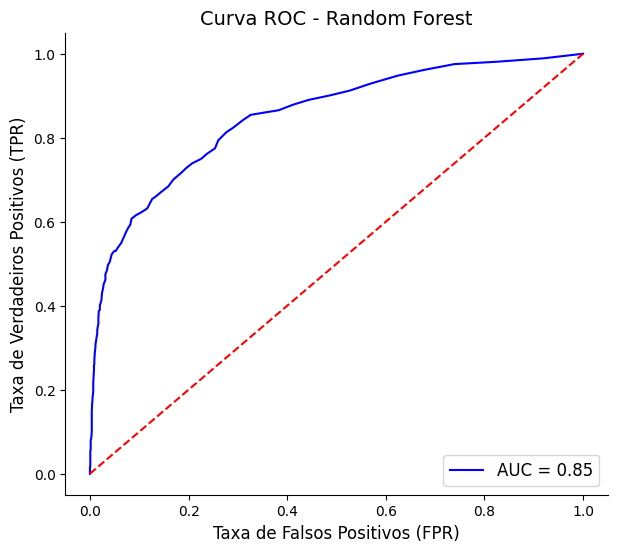

In [63]:

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)

roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))

# Plotar a Curva ROC
ax.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')

ax.plot([0, 1], [0, 1], color='red', linestyle='--')

ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)

ax.set_title('Curva ROC - Random Forest', fontsize=14)

ax.legend(loc='lower right', fontsize=12)

sns.despine()

plt.show()


In [ ]:
O valor de AUC obtido foi de 0.85, ou seja, o modelo tem 85% de chances de prever corretamente se os clientes irão ou não sair do banco.

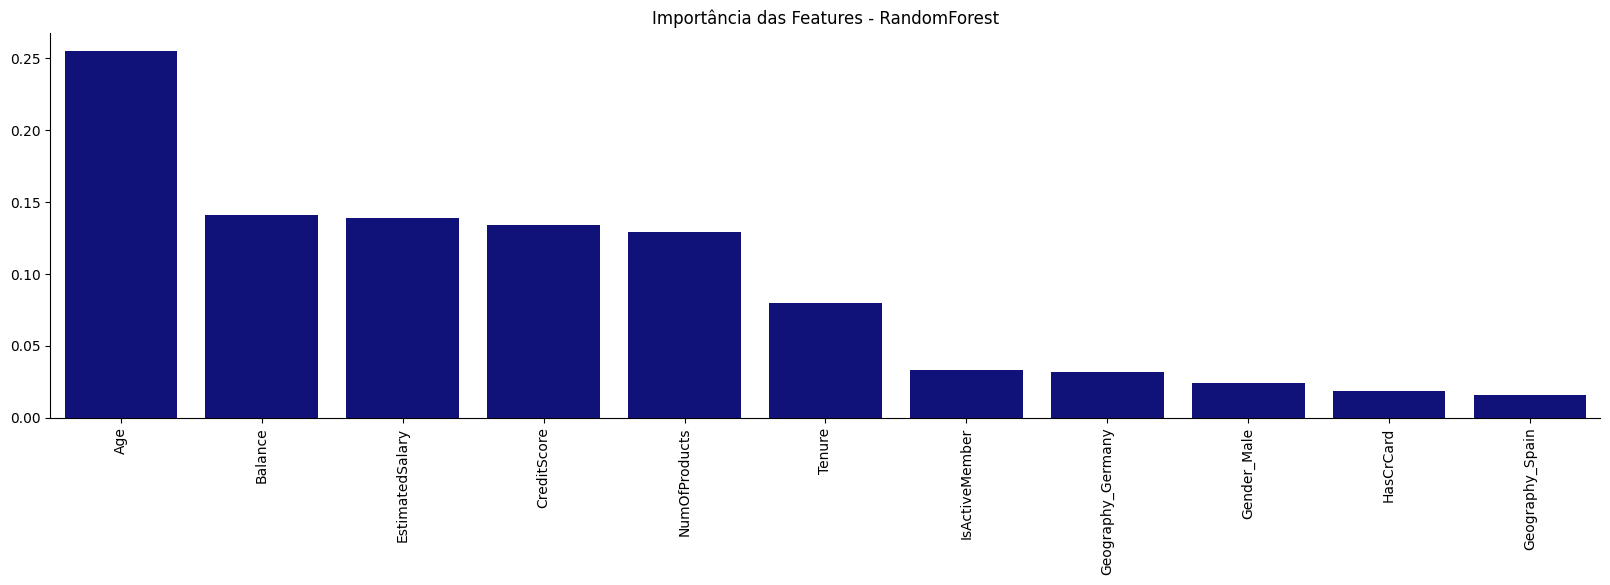

In [62]:
import numpy as np

importances = model_rf_balanced.feature_importances_
indexes = np.argsort(importances)[::-1]

coef = importances[indexes]

# Supondo que 'features' seja a lista de nomes das colunas
features_array = np.array(features.columns)

# Plotar gráfico de barras
fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(x=features_array[indexes], y=coef, ax=ax, color='darkblue')
plt.xticks(rotation=90)
sns.despine()

plt.title("Importância das Features - RandomForest")
plt.show()


Conclusão

- O modelo obtido tem 85% de chance de prever o comportamento do cliente.
- O que mais influencia se o cliente irá ou não deixar o banco é a idade (0.25), seguido do balanço, o salário estimado, o score de crédito e o número de produto (aprox. 0.15).

Com essas informações o banco poderá entender o perfil do cliente que quer deixá-lo e criar uma estratégia para oferecer mais benefícios para esse perfil de cliente, tornando o banco mais atraente, evitando a saída desse cliente.

